## Example 2:
Example workflow that trains a CNN to predict the amplitude and phase aberration coefficients from a z-stack,
using synthetic examples generated from the forwards model on-the-fly as training data.

In [1]:
import torch
import pytorch_lightning as pl

In [2]:
from cynosure.config import SimulationConfig, OpticalConfig, PriorConfig, ZernikeConfig, NoiseConfig
from cynosure.utilities.visualization import plot_stack
from cynosure.zstack_decoding import ZstackSolver, make_object_distribution

#### Simulation setup

In [3]:
# Simulation parameters:
pupil_grid_size = 255
object_grid_size = 31
object_pixel_size = 0.1  # um
rng_seed = 123

# Experimental parameters:
wavelength = 0.510  # um
focal_length = 4.50e3  # um
numerical_aperture = 0.9
medium_index = 1.54
immersion_index = 1.0
dz = 0.5  # um, physical objective z-step
bead_diameter = 0.1  # um

# Fitting parameters:
max_phase_order = 6  # max Zernike N
max_amplitude_order = 4  # max Zernike N
num_z = 7  # number of z-slices to fit, ~centered around the focal plane

device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
sim_cfg = SimulationConfig(
    pupil_grid_size=pupil_grid_size,
    object_grid_size=object_grid_size,
    object_pixel_size=object_pixel_size,
    ftype=torch.float32,
    ctype=torch.complex64,
)
opt_cfg = OpticalConfig(
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=numerical_aperture,
    aperture_type="fitted",
    medium_index=medium_index,
    immersion_index=immersion_index,
)
phase_cfg = ZernikeConfig(
    max_phase_order,
    allowed_nm=(
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -3), (3, -1), (3, 1), (3, 3),
        (4, -4), (4, -2), (4, 0), (4, 2), (4, 4),
        (5, -5), (5, -3), (5, -1), (5, 1), (5, 3), (5, 5),
    )
)
amp_cfg = ZernikeConfig(
    max_amplitude_order,
    allowed_nm=(
        (0, 0),
        (1, 1), (1, -1),
        (2, -2), (2, 0), (2, 2),
        (3, -1), (3, 1),
        (4, 0),
    )
)
noise_cfg = NoiseConfig(
    min_photons=100_000,
    max_photons=1_000_000,
    max_background=1_000,
    read_noise=10,
)

In [5]:
z = torch.arange(-(num_z//2), num_z//2 + 1).float() * dz
object_distrib = make_object_distribution(sim_cfg.object_grid_size, sim_cfg.object_pixel_size, bead_diameter)
phase_prior = PriorConfig(0.05, 1)
amp_prior = PriorConfig(0.05, 2)


#### Solver setup and training

In [6]:
solver = ZstackSolver(
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    z_objective=z,
    object_distribution=object_distrib,
    noise_cfg=noise_cfg,
    learning_rate=1e-3,
    weight_decay=1e-3,
    generator_chunk=16
)
solver = solver.to(device)

In [7]:
trainer = pl.Trainer(
    max_epochs=5,
    accelerator=device,
    log_every_n_steps=10,
)
trainer.fit(solver)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/walterf/projects/cynosure/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpo

Sanity Checking: |                                                                    | 0/? [00:00<?, ?it/s]

/home/walterf/projects/cynosure/.venv/lib/python3.14/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training: |                                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                                         | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


#### Sanity checking the results

In [8]:
batch_size = 4
images, phase_coefs, amp_coefs = solver.create_examples(batch_size)
pred_phase_coefs, pred_amp_coefs = solver.predict_coefficients(images)

pred_images = solver.simulate_normalized_stacks(pred_phase_coefs, pred_amp_coefs)

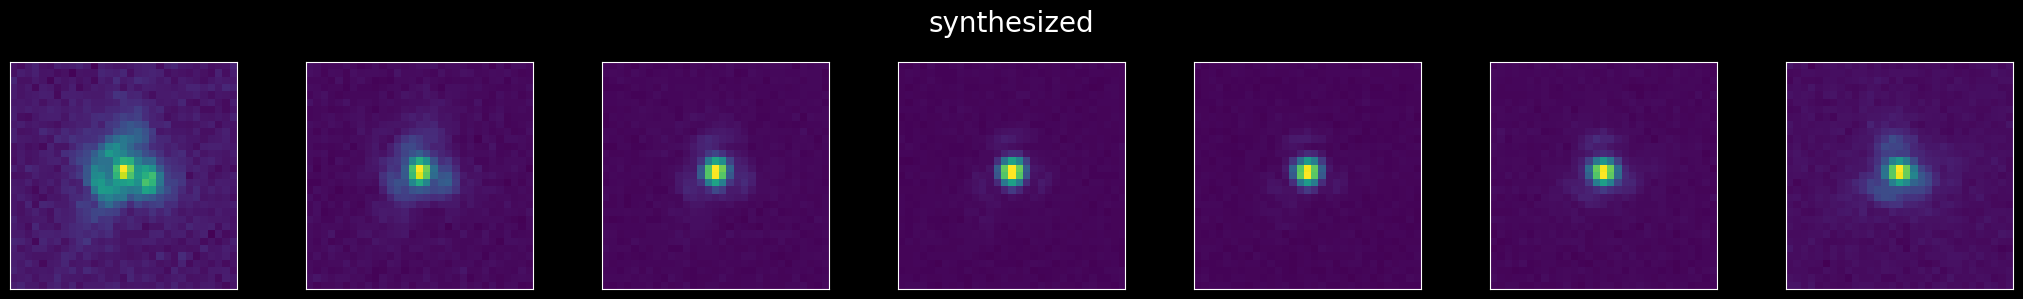

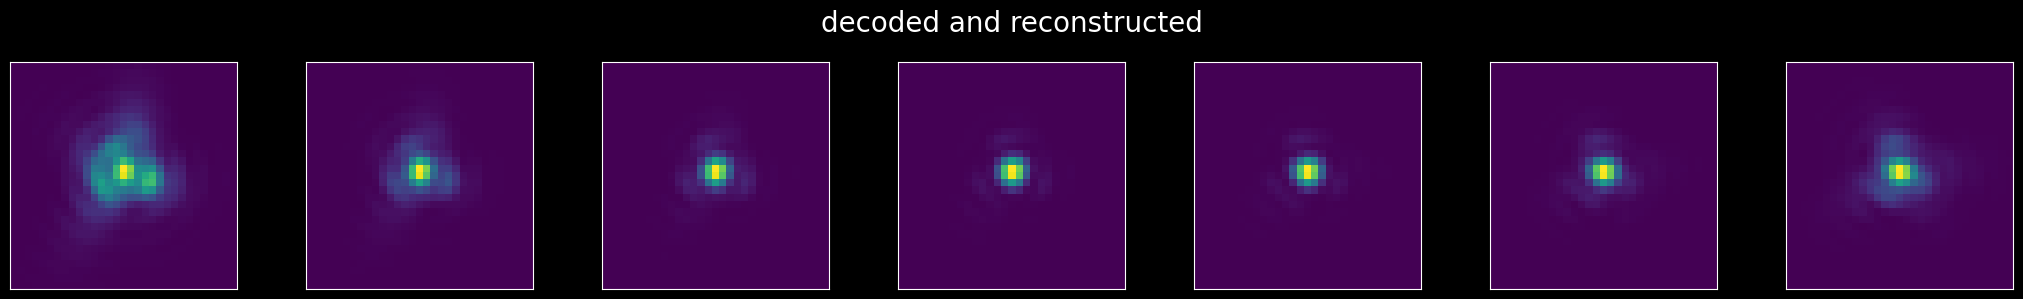

In [9]:
bidx = 0

fig1 = plot_stack(images.numpy(force=True)[bidx])
fig1.suptitle("synthesized", size=20)
fig1.tight_layout()

fig2 = plot_stack(pred_images.numpy(force=True)[bidx])
fig2.suptitle("decoded and reconstructed", size=20)
fig2.tight_layout()
